# Proyecto de Análisis de Datos  
## Brecha digital y condición de pobreza en los hogares salvadoreños  
### Encuesta de Hogares de Propósitos Múltiples (EHPM) – Preliminar 2025

**Asignatura:** Análisis de Datos  
**Fuente:** Encuesta de Hogares de Propósitos Múltiples (EHPM), El Salvador  
**Formato original:** SPSS (`.sav`)

### Pregunta general
**¿Existe una brecha en el acceso a internet y computadoras entre los hogares salvadoreños según su condición de pobreza y área geográfica durante 2025?**

### Objetivo general
Analizar las diferencias en el acceso a internet y computadora de los hogares salvadoreños según su condición de pobreza, área geográfica e ingreso per cápita.

### Preguntas analíticas
1. ¿Qué porcentaje de hogares tiene acceso a internet?
2. ¿Existe diferencia de acceso a internet entre área urbana y rural?
3. ¿Los hogares en condición de pobreza presentan menor acceso a internet?
4. ¿Qué porcentaje de hogares posee computadora?
5. ¿Cómo cambia la disponibilidad de computadora según pobreza y área?
6. ¿Los hogares con internet presentan mayor ingreso per cápita?

> El análisis se realizará a nivel de **hogar**. La base contiene registros de personas, por lo que varias características del hogar pueden repetirse entre sus miembros. Para evitar contar un mismo hogar varias veces se utilizará `IDBOLETA` como identificador.

# 0. Preparación del entorno

La EHPM se distribuye en formato SPSS. Pandas utiliza la librería `pyreadstat` para leer archivos `.sav`.

La siguiente celda instala las dependencias si todavía no están disponibles en el entorno de Jupyter.

In [2]:
# Ejecutar solo si alguna librería no está instalada.
%pip install -q pyreadstat pandas numpy matplotlib scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Fase I – Ingesta y perfilado inicial

## 1. Carga del dataset

El archivo original contiene más de 1,000 observaciones y muchas más de 8 variables, por lo que cumple con el requisito de volumen.

Se carga el archivo completo y posteriormente se seleccionan únicamente las variables necesarias para la investigación.

In [4]:
df = pd.read_spss("Base de datos EHPM 2025.sav")

print("Dimensiones del dataset original:", df.shape)
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


for col in df.columns:
    print(f"Columna: {col}")

Dimensiones del dataset original: (56463, 693)
Número de filas: 56463
Número de columnas: 693
Columna: ingreso_independientes
Columna: ingreso_agro
Columna: ingreso_pensiones
Columna: ingreso_remesas
Columna: edicion
Columna: lote
Columna: tipo
Columna: folio
Columna: viv
Columna: r101
Columna: idboleta
Columna: fac00
Columna: area
Columna: region
Columna: correlativo
Columna: municauto
Columna: estratoarea
Columna: codigomunic
Columna: autorrepresentado
Columna: znorte
Columna: r004
Columna: r005
Columna: r006
Columna: r015
Columna: r017
Columna: r017otr
Columna: R018
Columna: R019
Columna: R020
Columna: r021a
Columna: r021b
Columna: r022
Columna: r024
Columna: r033
Columna: r034
Columna: r036
Columna: r039
Columna: li
Columna: smin
Columna: actpr
Columna: actpr2012
Columna: actse
Columna: aproba1
Columna: ciuo414
Columna: ciiu416
Columna: ciuo436
Columna: ciiu438
Columna: d411b
Columna: d412b
Columna: gmed
Columna: gmvi
Columna: gmem
Columna: gmsa
Columna: h411a
Columna: h412a
Column

## 2. Variables seleccionadas

Para mantener el proyecto manejable se utilizará un subconjunto de variables relacionadas con características del hogar, pobreza, ingreso y acceso tecnológico.

| Variable | Uso en el proyecto |
|---|---|
| `IDBOLETA` | Identificador del hogar |
| `FAC00` | Factor de expansión |
| `AREA` | Área geográfica |
| `REGION` | Región geográfica |
| `R004` | Departamento |
| `POBREZA` | Condición de pobreza |
| `INGPE` | Ingreso per cápita del hogar |
| `R3213A` | Acceso a internet en el hogar |
| `R32309A` | Disponibilidad de computadora |
| `R32309B` | Número de computadoras |

In [5]:
columnas = [
    "idboleta", "fac00", "area", "region", "r004",
    "pobreza", "ingpe", "r3213a", "r32309a", "r32309b"
]

datos = df[columnas].copy()

print("Dimensiones del subconjunto inicial:", datos.shape)
datos.head(30)

Dimensiones del subconjunto inicial: (56463, 10)


,idboleta,fac00,area,region,r004,pobreza,ingpe,r3213a,r32309a,r32309b
0,"352,895.00",115.26,Urbano,Occidental,Ahuachapán,No pobre,570.67,No,No,NaN
1,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00
2,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00
3,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00
4,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00
5,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00
6,"352,897.00",125.83,Urbano,Occidental,Ahuachapán,No pobre,227.92,No,No,NaN
7,"352,897.00",125.83,Urbano,Occidental,Ahuachapán,No pobre,227.92,No,No,NaN
8,"352,897.00",125.83,Urbano,Occidental,Ahuachapán,No pobre,227.92,No,No,NaN
9,"352,898.00",115.26,Urbano,Occidental,Ahuachapán,Pobreza extrema,47.91,Sí,No,NaN


## 3. Construcción de la unidad de análisis: hogares

La EHPM registra miembros de los hogares. Como las variables seleccionadas corresponden principalmente al hogar, un mismo `IDBOLETA` puede aparecer varias veces.

Esto **no se considera un error del dataset**, sino una característica de su diseño. Para este proyecto se conserva un solo registro por hogar.

In [6]:
print("Registros antes de trabajar a nivel de hogar:", len(datos))
print("Hogares unicos:", datos["idboleta"].nunique())

hogares = datos.drop_duplicates(subset="idboleta").copy()

print("Registro despues de seleccionar un registro por hogar:", len(hogares))
print("Dimensiones del dataset a analizar:", hogares.shape)

Registros antes de trabajar a nivel de hogar: 56463
Hogares unicos: 17909
Registro despues de seleccionar un registro por hogar: 17909
Dimensiones del dataset a analizar: (17909, 10)


## 4. Verificación de tipos de datos (informacion general - tipos, cardinalidad y nulos)

In [7]:
hogares.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17909 entries, 0 to 56461
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   idboleta  17909 non-null  float64 
 1   fac00     17909 non-null  float64 
 2   area      17909 non-null  category
 3   region    17909 non-null  category
 4   r004      17909 non-null  category
 5   pobreza   17909 non-null  category
 6   ingpe     17909 non-null  float64 
 7   r3213a    17909 non-null  category
 8   r32309a   17909 non-null  category
 9   r32309b   8732 non-null   float64 
dtypes: category(6), float64(4)
memory usage: 805.9 KB


In [8]:
tipos = pd.DataFrame({
    "tipo_dato": hogares.dtypes.astype(str),
    "valores_no_nulos": hogares.notna().sum(),
    "valores_nulos": hogares.isna().sum(),
    "valores_unicos": hogares.nunique(dropna=True)
})

tipos

,tipo_dato,valores_no_nulos,valores_nulos,valores_unicos
idboleta,float64,17909,0,17909
fac00,float64,17909,0,9481
area,category,17909,0,2
region,category,17909,0,5
r004,category,17909,0,14
pobreza,category,17909,0,3
ingpe,float64,17909,0,13097
r3213a,category,17909,0,2
r32309a,category,17909,0,2
r32309b,float64,8732,9177,5


## 5. Cardinalidad

La cardinalidad indica cuántos valores diferentes presenta cada variable. Es útil para reconocer identificadores, variables categóricas y variables numéricas.

In [9]:
cardinalidad = hogares.nunique(dropna=True).sort_values(ascending=False)
cardinalidad

idboleta    17909
ingpe       13097
fac00        9481
r004           14
region          5
r32309b         5
pobreza         3
area            2
r3213a          2
r32309a         2
dtype: int64

## 6. Matriz / resumen inicial de valores nulos

Primero se mide la cantidad y porcentaje de valores faltantes. Todavía no se imputa nada: antes se debe entender qué significa cada ausencia.

In [10]:
nulos = pd.DataFrame({
    "nulos": hogares.isna().sum(),
    "porcentaje": hogares.isna().mean() * 100
}).sort_values("porcentaje", ascending=False)

nulos

,nulos,porcentaje
r32309b,9177,51.24
idboleta,0,0.00
fac00,0,0.00
area,0,0.00
region,0,0.00
r004,0,0.00
pobreza,0,0.00
ingpe,0,0.00
r3213a,0,0.00
r32309a,0,0.00


# Fase II – Análisis Exploratorio de Datos (EDA)

Antes de limpiar los datos se estudian sus distribuciones originales. Esto permite observar asimetrías, posibles valores atípicos y relaciones entre variables.

## 1. Estadística descriptiva inicial

In [11]:
hogares.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idboleta,"17,909.00",NaN,NaN,NaN,"358,318.97","6,160.40","347,453.00","352,967.00","358,387.00","363,713.00","368,747.00"
fac00,"17,909.00",NaN,NaN,NaN,114.09,91.29,5.49,51.22,79.86,143.62,379.04
area,17909,2,Urbano,9912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,17909,5,Oriental,4126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r004,17909,14,San Salvador,3584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pobreza,17909,3,No pobre,13654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingpe,"17,909.00",NaN,NaN,NaN,258.29,257.68,0.00,111.86,193.05,324.08,"7,202.75"
r3213a,17909,2,No,10069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r32309a,17909,2,No,9177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r32309b,"8,732.00",NaN,NaN,NaN,1.53,0.76,1.00,1.00,1.00,2.00,5.00


## 2. Distribución del ingreso per cápita

El ingreso suele presentar una distribución asimétrica: muchos hogares se concentran en ingresos bajos y medios, mientras una cantidad pequeña presenta valores muy altos.

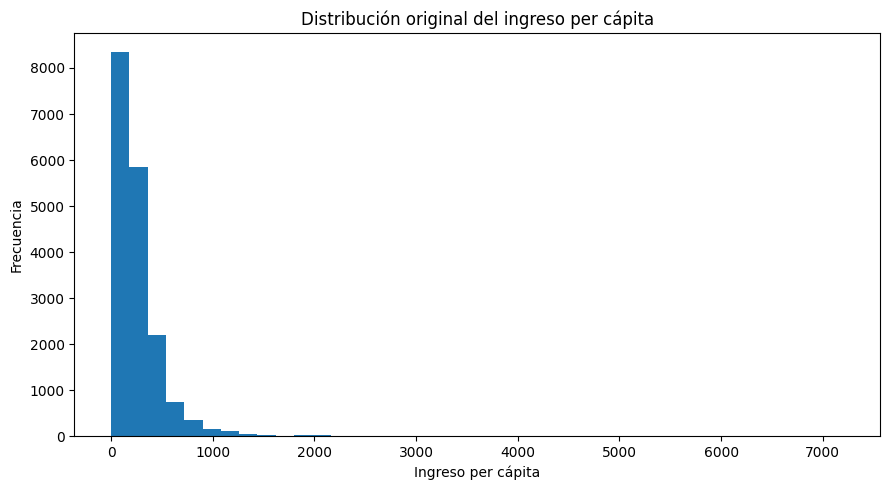

In [12]:
ingreso_original = pd.to_numeric(hogares["ingpe"], errors="coerce")

plt.figure(figsize=(9, 5))
plt.hist(ingreso_original.dropna(), bins=40)
plt.title("Distribución original del ingreso per cápita")
plt.xlabel("Ingreso per cápita")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### KDE del ingreso

La estimación de densidad KDE permite observar la forma general de la distribución sin depender exclusivamente de los intervalos del histograma.

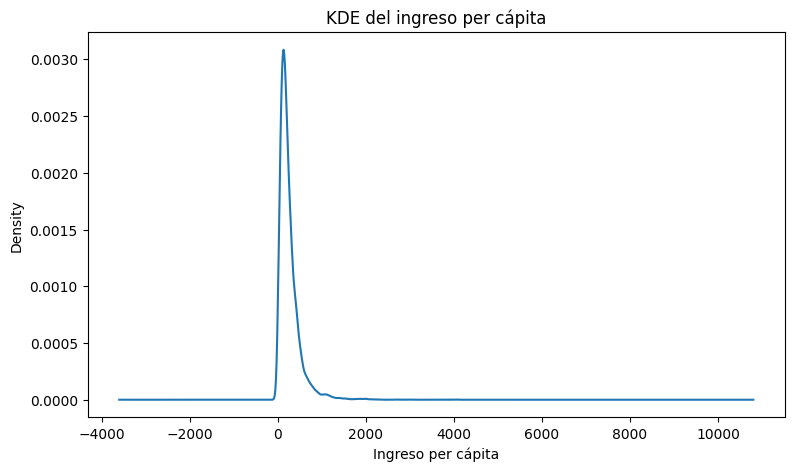

In [13]:
plt.figure(figsize=(9, 5))
ingreso_original.dropna().plot(kind="kde")
plt.title("KDE del ingreso per cápita")
plt.xlabel("Ingreso per cápita")
plt.show()

## 3. Distribuciones de variables categóricas

In [14]:
categoricas = ["area", "pobreza", "r3213a", "r32309a"]

for col in categoricas:
    print("\n", "=" * 60)
    print(col)
    print(hogares[col].value_counts(dropna=False))


area
area
Urbano    9912
Rural     7997
Name: count, dtype: int64

pobreza
pobreza
No pobre            13654
Pobreza relativa     2802
Pobreza extrema      1453
Name: count, dtype: int64

r3213a
r3213a
No    10069
Sí     7840
Name: count, dtype: int64

r32309a
r32309a
No    9177
Sí    8732
Name: count, dtype: int64


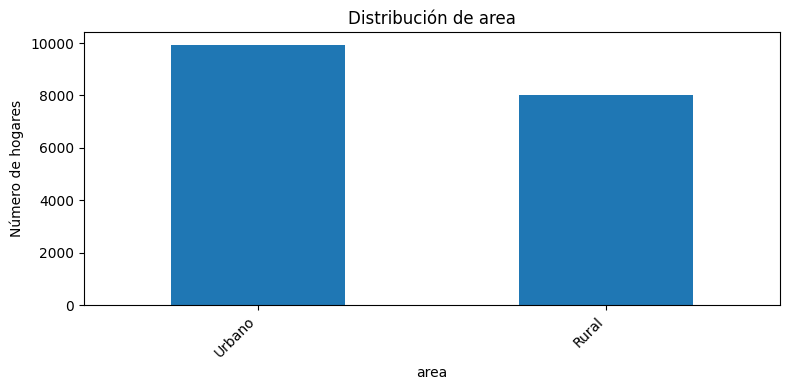

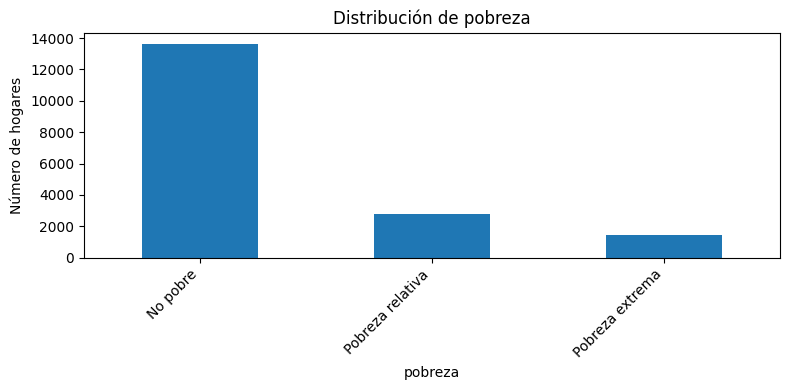

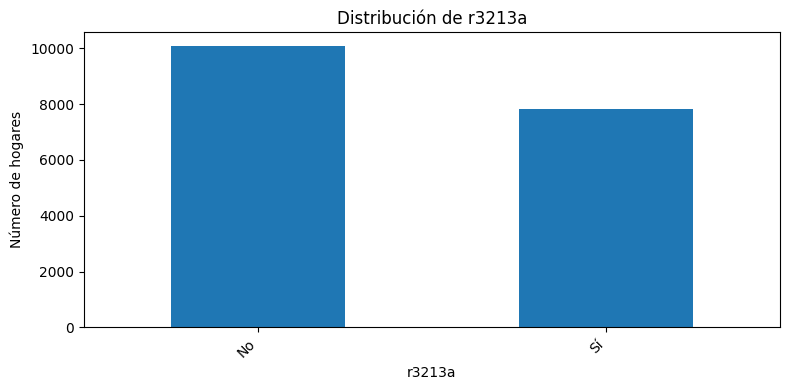

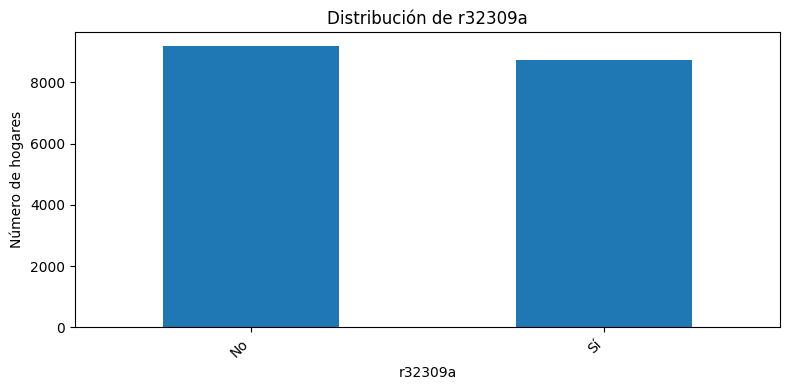

In [15]:
for col in categoricas:
    plt.figure(figsize=(8, 4))
    hogares[col].astype("string").fillna("Faltante").value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Número de hogares")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Correlaciones Pearson y Spearman

Se calculan únicamente entre variables numéricas.

- **Pearson:** mide relación lineal.
- **Spearman:** mide relación monotónica y es menos sensible a valores extremos.

No se interpreta una correlación como causalidad.

In [16]:
numericas = hogares[["fac00", "ingpe", "r32309b"]].copy()

for col in numericas.columns:
    numericas[col] = pd.to_numeric(numericas[col], errors="coerce")

print("Correlacin de Pearson")
display(numericas.corr(method="pearson"))

print("\nCorrelación de Spearman")
display(numericas.corr(method="spearman"))

Correlacin de Pearson


,fac00,ingpe,r32309b
fac00,1.00,0.07,-0.04
ingpe,0.07,1.00,-0.06
r32309b,-0.04,-0.06,1.00



Correlación de Spearman


,fac00,ingpe,r32309b
fac00,1.00,0.09,-0.03
ingpe,0.09,1.00,-0.13
r32309b,-0.03,-0.13,1.00


## 5. Preguntas analíticas

A partir del EDA se estudiarán las siguientes preguntas:

1. ¿Qué porcentaje de hogares tiene internet?
2. ¿Existe una brecha de internet entre área urbana y rural?
3. ¿Existe una brecha de internet según condición de pobreza?
4. ¿Qué porcentaje de hogares posee computadora?
5. ¿La disponibilidad de computadora cambia según pobreza y área?
6. ¿Los hogares con internet presentan diferente ingreso per cápita?

# Fase III – Limpieza de datos

La limpieza se realizará de forma justificada. No se eliminarán o imputarán datos simplemente porque aparezcan como faltantes.

## 1. Duplicados exactos y duplicados parciales

In [17]:
duplicados_exactos = hogares.duplicated().sum()
duplicados_id = hogares.duplicated(subset="idboleta").sum()

print("Duplicados exactos:", duplicados_exactos)
print("IDBOLETA repetidos después de construir la base de hogares:", duplicados_id)

Duplicados exactos: 0
IDBOLETA repetidos después de construir la base de hogares: 0


In [18]:
# Eliminamos únicamente duplicados exactos, si existieran.
hogares_limpio = hogares.drop_duplicates().copy()

print("Filas antes:", len(hogares))
print("Filas después:", len(hogares_limpio))




Filas antes: 17909
Filas después: 17909


## 2. Estandarización de cadenas de texto

Las variables categóricas pueden presentar diferencias de mayúsculas, minúsculas o espacios. Se normalizan sin alterar su significado.

In [19]:
def limpiar_texto(serie):
    return (
        serie.astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

for col in ["area", "region", "r004", "pobreza", "r3213a", "r32309a"]:
    hogares_limpio[col] = limpiar_texto(hogares_limpio[col])


hogares_limpio[["area", "pobreza", "r3213a", "r32309a"]].head()
hogares_limpio["area"].unique()
hogares_limpio["pobreza"].unique()
hogares_limpio["r3213a"].unique()
hogares_limpio["r32309a"].unique()

<StringArray>
['No', 'Sí']
Length: 2, dtype: string

## 3. Tratamiento de valores nulos

Se distinguen dos situaciones:

- `INGPE`: si existen faltantes, se utilizará la **mediana**, porque el ingreso suele ser asimétrico y la mediana es menos sensible a valores extremos que la media.
- `R32309B`: representa el número de computadoras. Antes de imputar se revisa su relación con la respuesta de tenencia de computadora para identificar faltantes estructurales.

No se imputan variables categóricas a ciegas; los valores faltantes se mantienen como categoría `"No especificado"` cuando sea necesario para análisis descriptivo.

In [20]:
print(hogares_limpio["r32309a"].isna().sum())

0


In [21]:
# Convertimos variables numéricas
hogares_limpio["ingpe"] = pd.to_numeric(hogares_limpio["ingpe"], errors="coerce")
hogares_limpio["r32309b"] = pd.to_numeric(hogares_limpio["r32309b"], errors="coerce")

print("Nulos en INGPE:", hogares_limpio["ingpe"].isna().sum())
print("Nulos en R32309A:", hogares_limpio["r32309a"].isna().sum())
print("Nulos en R32309B:", hogares_limpio["r32309b"].isna().sum())


Nulos en INGPE: 0
Nulos en R32309A: 0
Nulos en R32309B: 9177


### Número de computadoras

Cuando una variable de cantidad está vacía porque el hogar respondió que **no posee** el bien, el valor faltante puede ser estructural y representar cero.

La siguiente función convierte respuestas Sí/No en 1/0 utilizando las etiquetas del archivo SPSS.

In [22]:
def internet_si_no(serie):
    texto = (
        serie.astype("string")
        .str.strip()
        .str.lower()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
    )

    resultado = pd.Series(np.nan, index=serie.index, dtype="float64")
    resultado[texto.str.startswith("si", na=False)] = 1
    resultado[texto.str.startswith("no", na=False)] = 0
    return resultado

hogares_limpio["INTERNET_SI_NO"] = internet_si_no(hogares_limpio["r3213a"])
hogares_limpio["COMPUTADORA_SI_NO"] = internet_si_no(hogares_limpio["r32309a"])

print("Valores originales de si tiene internet:")
print(hogares_limpio["r3213a"].value_counts(dropna=False))

print("\nConversion :")
print(hogares_limpio["INTERNET_SI_NO"].value_counts(dropna=False))


print("\nValores originales de si tienen computadora:")
print(hogares_limpio["r32309a"].value_counts(dropna=False))

print("\nConversion :")
print(hogares_limpio["COMPUTADORA_SI_NO"].value_counts(dropna=False))

Valores originales de si tiene internet:
r3213a
No    10069
Sí     7840
Name: count, dtype: Int64

Conversion :
INTERNET_SI_NO
0.00    10069
1.00     7840
Name: count, dtype: int64

Valores originales de si tienen computadora:
r32309a
No    9177
Sí    8732
Name: count, dtype: Int64

Conversion :
COMPUTADORA_SI_NO
0.00    9177
1.00    8732
Name: count, dtype: int64


In [23]:
hogares_limpio[["COMPUTADORA_SI_NO", "r32309b"]].head(10)

copia1 = hogares_limpio.copy()


In [24]:
# Si el hogar explícitamente indica que NO tiene computadora,
# un R32309B faltante se interpreta como 0 computadoras.


condicion_cero = (
    (hogares_limpio["COMPUTADORA_SI_NO"] == 0) &
    (hogares_limpio["r32309b"].isna())
)



hogares_limpio.loc[condicion_cero, "r32309b"] = 0

 # Si aún quedan faltantes entre hogares que sí poseen computadora,
# se utiliza la mediana de los hogares con computadora.
mediana_pc = hogares_limpio.loc[
    hogares_limpio["COMPUTADORA_SI_NO"] == 1, "r32309b"
].median()


#Condicion que solo aplica para hogares que tienen computadora y aún tienen el valor faltante en r32309b(Cantidad de computadoras)
condicion_imputar_pc = (
    (hogares_limpio["COMPUTADORA_SI_NO"] == 1) &
    (hogares_limpio["r32309b"].isna())
)

hogares_limpio.loc[condicion_imputar_pc, "r32309b"] = mediana_pc

print("Mediana de computadoras entre hogares con computadora:", mediana_pc)

print("Nulos restantes en r32309b:", hogares_limpio["r32309b"].isna().sum())


hogares_limpio.head(30)






Mediana de computadoras entre hogares con computadora: 1.0
Nulos restantes en r32309b: 0


,idboleta,fac00,area,region,r004,pobreza,ingpe,r3213a,r32309a,r32309b,INTERNET_SI_NO,COMPUTADORA_SI_NO
0,"352,895.00",115.26,Urbano,Occidental,Ahuachapán,No pobre,570.67,No,No,0.00,0.00,0.00
1,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00,1.00,1.00
6,"352,897.00",125.83,Urbano,Occidental,Ahuachapán,No pobre,227.92,No,No,0.00,0.00,0.00
9,"352,898.00",115.26,Urbano,Occidental,Ahuachapán,Pobreza extrema,47.91,Sí,No,0.00,1.00,0.00
11,"352,899.00",125.83,Urbano,Occidental,Ahuachapán,Pobreza relativa,120.00,Sí,No,0.00,1.00,0.00
14,"352,900.00",115.26,Urbano,Occidental,Ahuachapán,Pobreza extrema,2.50,Sí,No,0.00,1.00,0.00
15,"352,902.00",115.26,Urbano,Occidental,Ahuachapán,No pobre,601.00,Sí,No,0.00,1.00,0.00
16,"352,903.00",131.12,Urbano,Occidental,Ahuachapán,No pobre,300.00,Sí,No,0.00,1.00,0.00
18,"349,326.00",239.74,Urbano,Occidental,Ahuachapán,No pobre,220.21,No,No,0.00,0.00,0.00
22,"349,328.00",239.74,Urbano,Occidental,Ahuachapán,Pobreza relativa,80.71,No,No,0.00,0.00,0.00


## 4. Detección cuantitativa de outliers mediante IQR

Se utiliza:

\[
IQR = Q3 - Q1
\]

Límites:

\[
Límite\ inferior = Q1 - 1.5(IQR)
\]

\[
Límite\ superior = Q3 + 1.5(IQR)
\]

Se aplica al ingreso per cápita. Los ingresos extremos pueden ser valores reales, por lo que **no se eliminan las observaciones**. Para el pipeline se crea una versión limitada conservando siempre el dato original.

In [25]:
Q1 = hogares_limpio["ingpe"].quantile(0.25)
Q3 = hogares_limpio["ingpe"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = (
    (hogares_limpio["ingpe"] < lim_inf) |
    (hogares_limpio["ingpe"] > lim_sup)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)
print("Cantidad de outliers:", outliers.sum())
print("Porcentaje de outliers:", round(outliers.mean() * 100, 2), "%")

Q1: 111.855
Q3: 324.0825
IQR: 212.22749999999996
Límite inferior: -206.48624999999993
Límite superior: 642.4237499999999
Cantidad de outliers: 1033
Porcentaje de outliers: 5.77 %


In [26]:
hogares_limpio["es_outlier_ingreso"] = outliers
hogares_limpio

,idboleta,fac00,area,region,r004,pobreza,ingpe,r3213a,r32309a,r32309b,INTERNET_SI_NO,COMPUTADORA_SI_NO,es_outlier_ingreso
0,"352,895.00",115.26,Urbano,Occidental,Ahuachapán,No pobre,570.67,No,No,0.00,0.00,0.00,False
1,"352,896.00",127.95,Urbano,Occidental,Ahuachapán,Pobreza extrema,24.00,Sí,Sí,2.00,1.00,1.00,False
6,"352,897.00",125.83,Urbano,Occidental,Ahuachapán,No pobre,227.92,No,No,0.00,0.00,0.00,False
9,"352,898.00",115.26,Urbano,Occidental,Ahuachapán,Pobreza extrema,47.91,Sí,No,0.00,1.00,0.00,False
11,"352,899.00",125.83,Urbano,Occidental,Ahuachapán,Pobreza relativa,120.00,Sí,No,0.00,1.00,0.00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56453,"366,909.00",72.20,Rural,Oriental,La Unión,No pobre,333.33,Sí,Sí,1.00,1.00,1.00,False
56455,"366,910.00",68.48,Rural,Oriental,La Unión,No pobre,400.00,Sí,No,0.00,1.00,0.00,False
56458,"366,911.00",72.20,Rural,Oriental,La Unión,No pobre,216.75,No,No,0.00,0.00,0.00,False
56460,"366,912.00",61.03,Rural,Oriental,La Unión,No pobre,708.33,No,No,0.00,0.00,0.00,True


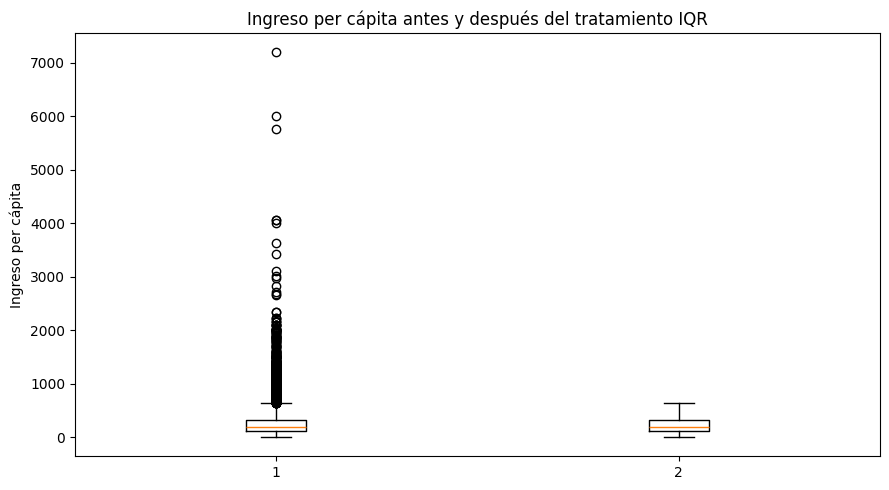

In [27]:
hogares_limpio["INGPE_LIMPIO"] = hogares_limpio["ingpe"].clip(
    lower=lim_inf,
    upper=lim_sup
)

plt.figure(figsize=(9, 5))
plt.boxplot(
    [
        hogares_limpio["ingpe"].dropna(),
        hogares_limpio["INGPE_LIMPIO"].dropna()
    ],
    label=["Antes", "Después"]
)
plt.title("Ingreso per cápita antes y después del tratamiento IQR")
plt.ylabel("Ingreso per cápita")
plt.tight_layout()
plt.show()

# Fase IV – Transformación, normalización e ingeniería de características

## 1. Ingeniería de características

Se crea una variable de **brecha digital**:

- `0`: hogar con internet y computadora.
- `1`: hogar sin al menos uno de estos dos recursos.

También se crea el logaritmo del ingreso para disponer de una variable menos asimétrica.

In [28]:
hogares_limpio["BRECHA_DIGITAL"] = np.where(
    (hogares_limpio["INTERNET_SI_NO"] == 1) &
    (hogares_limpio["COMPUTADORA_SI_NO"] == 1),
    0,
    np.where(
        hogares_limpio[["INTERNET_SI_NO", "COMPUTADORA_SI_NO"]].notna().all(axis=1),
        1,
        np.nan
    )
)

hogares_limpio["LOG_INGPE"] = np.log1p(hogares_limpio["INGPE_LIMPIO"])

hogares_limpio[
    ["INGPE_LIMPIO", "LOG_INGPE", "INTERNET_SI_NO", "COMPUTADORA_SI_NO", "BRECHA_DIGITAL"]
].head()

,INGPE_LIMPIO,LOG_INGPE,INTERNET_SI_NO,COMPUTADORA_SI_NO,BRECHA_DIGITAL
0,570.67,6.35,0.00,0.00,1.00
1,24.00,3.22,1.00,1.00,0.00
6,227.92,5.43,0.00,0.00,1.00
9,47.91,3.89,1.00,0.00,1.00
11,120.00,4.80,1.00,0.00,1.00


## 2. Escalado numérico: RobustScaler

Se utiliza **RobustScaler** para el ingreso y número de computadoras porque el análisis inicial puede mostrar distribuciones asimétricas y presencia de valores extremos.

RobustScaler utiliza la mediana y el rango intercuartílico, por lo que es menos sensible a outliers que StandardScaler.

In [29]:
variables_escalar = ["INGPE_LIMPIO", "r32309b"]

scaler = RobustScaler()

escaladas = scaler.fit_transform(hogares_limpio[variables_escalar])

hogares_limpio["INGPE_ESCALADO"] = escaladas[:, 0]
hogares_limpio["PC_ESCALADO"] = escaladas[:, 1]

hogares_limpio[
    ["INGPE_LIMPIO", "INGPE_ESCALADO", "r32309b", "PC_ESCALADO"]
].head()

,INGPE_LIMPIO,INGPE_ESCALADO,r32309b,PC_ESCALADO
0,570.67,1.78,0.00,0.00
1,24.00,-0.80,2.00,2.00
6,227.92,0.16,0.00,0.00
9,47.91,-0.68,0.00,0.00
11,120.00,-0.34,0.00,0.00


## 3. Codificación de variables categóricas

Se utiliza **One-Hot Encoding** para `AREA` y `POBREZA`.

Se aplica `drop_first=True` para evitar la **trampa de las variables ficticias**, es decir, generar columnas categóricas perfectamente redundantes que pueden producir multicolinealidad en modelos futuros.

In [30]:
categorias_modelo = hogares_limpio[["area", "pobreza"]].fillna("No especificado")

dummies = pd.get_dummies(
    categorias_modelo,
    columns=["area", "pobreza"],
    drop_first=True,
    dtype=int
)

dummies.head()

,area_Urbano,pobreza_Pobreza extrema,pobreza_Pobreza relativa
0,1,0,0
1,1,1,0
6,1,0,0
9,1,1,0
11,1,0,1


In [31]:
dataset_procesado = pd.concat(
    [
        hogares_limpio.reset_index(drop=True),
        dummies.reset_index(drop=True)
    ],
    axis=1
)

print("Dimensiones finales:", dataset_procesado.shape)
dataset_procesado.tail(30)

Dimensiones finales: (17909, 21)


,idboleta,fac00,area,region,r004,pobreza,ingpe,r3213a,r32309a,r32309b,INTERNET_SI_NO,COMPUTADORA_SI_NO,es_outlier_ingreso,INGPE_LIMPIO,BRECHA_DIGITAL,LOG_INGPE,INGPE_ESCALADO,PC_ESCALADO,area_Urbano,pobreza_Pobreza extrema,pobreza_Pobreza relativa
17879,"363,309.00",95.51,Rural,Oriental,La Unión,Pobreza relativa,55.61,No,Sí,1.00,0.00,1.00,False,55.61,1.00,4.04,-0.65,1.00,0,0,1
17880,"363,311.00",90.82,Rural,Oriental,La Unión,No pobre,135.01,No,Sí,1.00,0.00,1.00,False,135.01,1.00,4.91,-0.27,1.00,0,0,0
17881,"363,312.00",82.39,Rural,Oriental,La Unión,Pobreza extrema,21.08,No,Sí,3.00,0.00,1.00,False,21.08,1.00,3.09,-0.81,3.00,0,1,0
17882,"363,313.00",104.88,Rural,Oriental,La Unión,No pobre,200.84,Sí,Sí,1.00,1.00,1.00,False,200.84,0.00,5.31,0.04,1.00,0,0,0
17883,"363,314.00",88.01,Rural,Oriental,La Unión,No pobre,88.12,Sí,Sí,2.00,1.00,1.00,False,88.12,0.00,4.49,-0.49,2.00,0,0,0
17884,"363,315.00",76.77,Rural,Oriental,La Unión,Pobreza relativa,75.00,No,No,0.00,0.00,0.00,False,75.00,1.00,4.33,-0.56,0.00,0,0,1
17885,"366,890.00",48.78,Urbano,Oriental,La Unión,No pobre,301.25,Sí,No,0.00,1.00,0.00,False,301.25,1.00,5.71,0.51,0.00,1,0,0
17886,"366,891.00",54.22,Urbano,Oriental,La Unión,No pobre,269.67,Sí,No,0.00,1.00,0.00,False,269.67,1.00,5.60,0.36,0.00,1,0,0
17887,"366,892.00",62.38,Urbano,Oriental,La Unión,No pobre,183.33,No,No,0.00,0.00,0.00,False,183.33,1.00,5.22,-0.05,0.00,1,0,0
17888,"366,893.00",52.18,Urbano,Oriental,La Unión,No pobre,147.00,Sí,Sí,1.00,1.00,1.00,False,147.00,0.00,5.00,-0.22,1.00,1,0,0


# Preguntas analíticas y resultados

## Pregunta 1 – ¿Qué porcentaje de hogares tiene acceso a internet?

In [32]:
resultado_internet = hogares_limpio["INTERNET_SI_NO"].value_counts(normalize=True).sort_index() * 100
resultado_internet

INTERNET_SI_NO
0.00   56.22
1.00   43.78
Name: proportion, dtype: float64

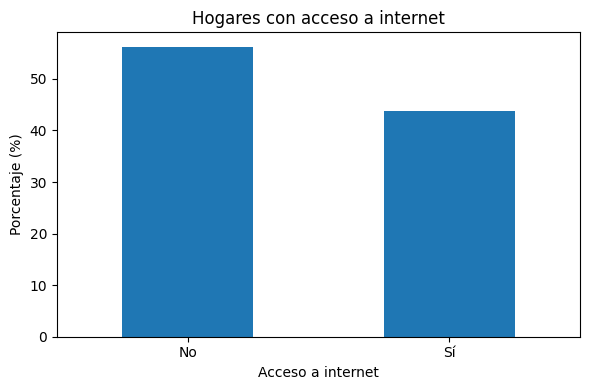

In [33]:
plt.figure(figsize=(6, 4))
resultado_internet.rename(index={0.0: "No", 1.0: "Sí"}).plot(kind="bar")
plt.title("Hogares con acceso a internet")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Acceso a internet")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Pregunta 2 – ¿Existe diferencia entre área geográfica y acceso a internet?

In [34]:
internet_area = pd.crosstab(
    hogares_limpio["area"],
    hogares_limpio["INTERNET_SI_NO"],
    normalize="index"
) * 100

internet_area

INTERNET_SI_NO,0.00,1.00
area,,
Rural,74.98,25.02
Urbano,41.09,58.91


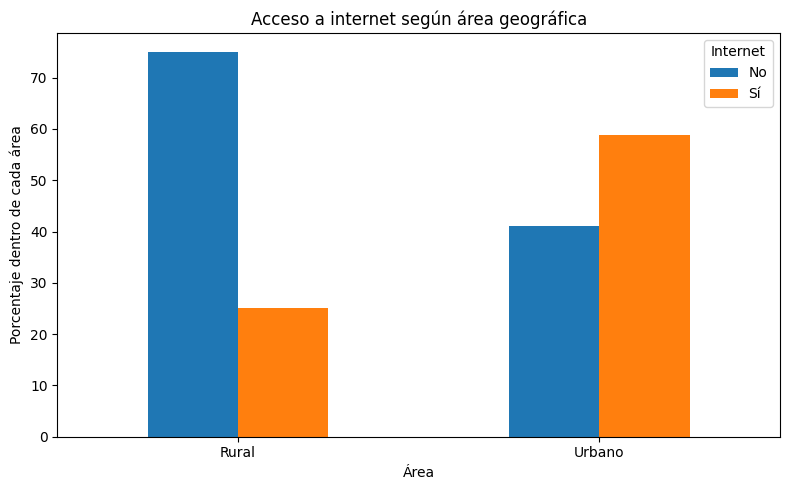

In [35]:
internet_area.rename(columns={0.0: "No", 1.0: "Sí"}).plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Acceso a internet según área geográfica")
plt.ylabel("Porcentaje dentro de cada área")
plt.xlabel("Área")
plt.xticks(rotation=0)
plt.legend(title="Internet")
plt.tight_layout()
plt.show()

## Pregunta 3 – ¿Existe diferencia según condición de pobreza?

In [36]:
internet_pobreza = pd.crosstab(
    hogares_limpio["pobreza"],
    hogares_limpio["INTERNET_SI_NO"],
    normalize="index"
) * 100

internet_pobreza

INTERNET_SI_NO,0.00,1.00
pobreza,,
No pobre,52.20,47.80
Pobreza extrema,77.70,22.30
Pobreza relativa,64.67,35.33


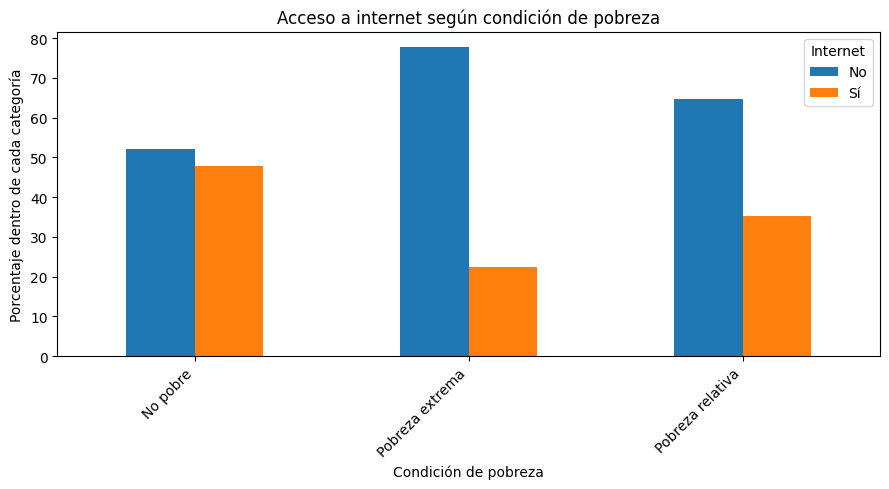

In [37]:
internet_pobreza.rename(columns={0.0: "No", 1.0: "Sí"}).plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Acceso a internet según condición de pobreza")
plt.ylabel("Porcentaje dentro de cada categoría")
plt.xlabel("Condición de pobreza")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Internet")
plt.tight_layout()
plt.show()

## Pregunta 4 – ¿Qué porcentaje de hogares posee computadora?

In [38]:
resultado_pc = hogares_limpio["COMPUTADORA_SI_NO"].value_counts(normalize=True).sort_index() * 100
resultado_pc

COMPUTADORA_SI_NO
0.00   51.24
1.00   48.76
Name: proportion, dtype: float64

## Pregunta 5 – ¿Cómo cambia la disponibilidad de computadora según pobreza y área?

In [39]:
pc_pobreza = pd.crosstab(
    hogares_limpio["pobreza"],
    hogares_limpio["COMPUTADORA_SI_NO"],
    normalize="index"
) * 100

pc_area = pd.crosstab(
    hogares_limpio["area"],
    hogares_limpio["COMPUTADORA_SI_NO"],
    normalize="index"
) * 100

print("Computadora según pobreza")
display(pc_pobreza)

print("\nComputadora según área")
display(pc_area)

Computadora según pobreza


COMPUTADORA_SI_NO,0.00,1.00
pobreza,,
No pobre,51.87,48.13
Pobreza extrema,55.40,44.60
Pobreza relativa,46.00,54.00



Computadora según área


COMPUTADORA_SI_NO,0.00,1.00
area,,
Rural,53.77,46.23
Urbano,49.20,50.80


## Pregunta 6 – ¿Los hogares con internet presentan mayor ingreso per cápita?

Se compara la mediana del ingreso, ya que es más robusta ante distribuciones asimétricas.

In [40]:
ingreso_internet = hogares_limpio.groupby("INTERNET_SI_NO")["ingpe"].agg(
    ["count", "mean", "median", "std"]
)

ingreso_internet.rename(index={0.0: "Sin internet", 1.0: "Con internet"})

,count,mean,median,std
INTERNET_SI_NO,,,,
Sin internet,10069,205.21,158.83,197.22
Con internet,7840,326.46,245.39,305.73


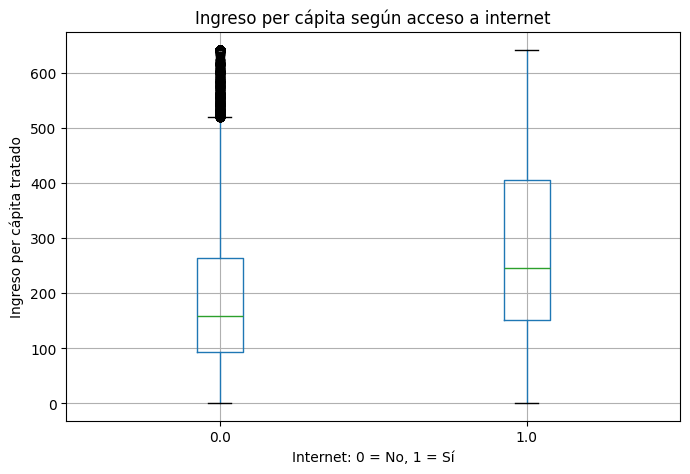

In [41]:
hogares_limpio.boxplot(
    column="INGPE_LIMPIO",
    by="INTERNET_SI_NO",
    figsize=(7, 5)
)
plt.title("Ingreso per cápita según acceso a internet")
plt.suptitle("")
plt.xlabel("Internet: 0 = No, 1 = Sí")
plt.ylabel("Ingreso per cápita tratado")
plt.tight_layout()
plt.show()

# Fase V – Auditoría y comparación pre/post procesamiento

Se comparan las métricas del ingreso antes y después del tratamiento.

Las métricas utilizadas son:

- Media
- Desviación estándar
- Asimetría (skewness)
- Curtosis

El objetivo no es obligar a la distribución a ser normal, sino demostrar de forma cuantitativa cómo cambió después del tratamiento.

In [42]:
def metricas(serie):
    s = pd.Series(serie).dropna()
    return pd.Series({
        "media": s.mean(),
        "desviacion_estandar": s.std(),
        "asimetria": s.skew(),
        "curtosis": s.kurt()
    })

auditoria = pd.DataFrame({
    "Antes": metricas(hogares_limpio["ingpe"]),
    "Después": metricas(hogares_limpio["INGPE_LIMPIO"])
})

auditoria

,Antes,Después
media,258.29,237.86
desviacion_estandar,257.68,168.15
asimetria,5.49,0.97
curtosis,77.25,0.14


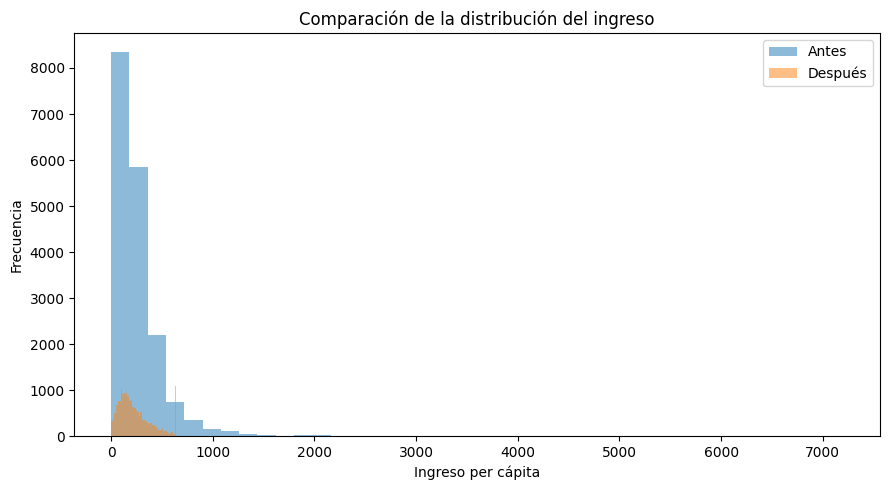

In [43]:
plt.figure(figsize=(9, 5))
plt.hist(
    hogares_limpio["ingpe"].dropna(),
    bins=40,
    alpha=0.5,
    label="Antes"
)
plt.hist(
    hogares_limpio["INGPE_LIMPIO"].dropna(),
    bins=40,
    alpha=0.5,
    label="Después"
)
plt.title("Comparación de la distribución del ingreso")
plt.xlabel("Ingreso per cápita")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

# Resumen de calidad del dataset

Al finalizar el pipeline se vuelve a calcular el porcentaje de valores nulos de las variables principales.

In [44]:
comparacion_nulos = pd.DataFrame({
    "Antes_%": hogares.isna().mean() * 100,
    "Después_%": hogares_limpio[
        [c for c in hogares.columns if c in hogares_limpio.columns]
    ].isna().mean() * 100
})

comparacion_nulos.sort_values("Antes_%", ascending=False)

,Antes_%,Después_%
r32309b,51.24,0.00
idboleta,0.00,0.00
fac00,0.00,0.00
area,0.00,0.00
region,0.00,0.00
r004,0.00,0.00
pobreza,0.00,0.00
ingpe,0.00,0.00
r3213a,0.00,0.00
r32309a,0.00,0.00


# Conclusiones – guía para redactarlas después de ejecutar

Después de ejecutar todo el notebook, redactar entre **3 y 5 conclusiones breves** basadas exclusivamente en los resultados obtenidos.

Ejemplo de estructura:

1. **Acceso a internet:** indicar el porcentaje encontrado de hogares con y sin internet.
2. **Brecha territorial:** indicar si el área rural presenta menor acceso que la urbana y por cuánto.
3. **Pobreza:** indicar si los hogares en condición de pobreza presentan menor acceso tecnológico.
4. **Ingreso:** comparar la mediana de ingreso de hogares con y sin internet.
5. **Calidad de datos:** explicar qué problemas fueron detectados y cómo fueron tratados.

## Decisiones metodológicas principales

- Se trabajó a nivel de hogar utilizando `IDBOLETA`.
- No se confundieron repeticiones por miembro del hogar con duplicados erróneos.
- Los valores faltantes fueron analizados antes de imputarse.
- El ingreso faltante se imputó mediante mediana por su posible asimetría.
- Los outliers de ingreso se detectaron mediante IQR.
- Los valores extremos no se eliminaron; se conservó la variable original y se creó una versión limitada para el pipeline.
- Se utilizó RobustScaler debido a la presencia esperada de asimetría y valores extremos.
- Las variables categóricas se codificaron con One-Hot Encoding y `drop_first=True`.
- Se creó una variable derivada de brecha digital con valor analítico.

## Resultado esperado del proyecto

El notebook deja un dataset preparado para análisis estadístico y para un posible modelo predictivo futuro, manteniendo trazabilidad entre los datos originales y las variables procesadas.

In [45]:
dataset_csv = hogares_limpio.to_csv("dataset_Brecha_Digital_Proyecto.csv", index=False, encoding="utf-8")

In [46]:
dataset_csv.

SyntaxError: invalid syntax (3553031020.py, line 1)